In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import memory_profiler
import signal

/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Dynamic Programming

In [2]:
def knapsack_recursive(values, weights, W, i=0, memo=None):
    if memo is None:
        memo = {}

    if i >= len(values):
        return [], 0  # Retorna lista vazia e valor 0 quando não há mais itens para avaliar

    if (i, W) in memo:
        return memo[(i, W)]

    # Caso 1: Não pegar o item
    best_solution, best_value = knapsack_recursive(values, weights, W, i + 1, memo)

    # Caso 2: Pegar o item, se couber na mochila
    if weights[i] <= W:
        taken_solution, taken_value = knapsack_recursive(values, weights, W - weights[i], i + 1, memo)
        taken_value += values[i]

        if taken_value > best_value:
            best_value = taken_value
            best_solution = [1] + taken_solution  # Marca item como escolhido
        else:
            best_solution = [0] + best_solution  # Marca item como não escolhido
    else:
        best_solution = [0] + best_solution  # Marca item como não escolhido

    memo[(i, W)] = (best_solution, best_value)
    return memo[(i, W)]


def knapsack_BU(values, weights, W):
    W = int(W)
    n = len(values)

    dp = [[0] * (W + 1) for _ in range(n + 1)] # Zero Matrix with (n+1) rows and (W+1) columns
    selected = [[[] for _ in range(W + 1)] for _ in range(n + 1)]  # to keep chosen itens

    for i in range(n): # for each item 
        wi = int(weights[i])

        for x in range(W + 1): # Cycle through all possible backpack capacities
            # Case 2: Don't take the item
            dp[i + 1][x] = dp[i][x]
            selected[i + 1][x] = selected[i][x]  # keep previous choices

            # Case 1: Take the item
            if wi <= x and values[i] + dp[i][x - wi] > dp[i + 1][x]: # checks if it fits in the backpack
                dp[i + 1][x] = values[i] + dp[i][x - wi]
                selected[i + 1][x] = selected[i][x - wi] + [i]  # adds the item

    # The maximum possible value is in the last cell of the matrix
    best_solution = [1 if i in selected[n][W] else 0 for i in range(n)]
    return best_solution, dp[n][W]

### Branch and Bound

In [3]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level # niveau dans l’arbre de recherche >=0
        self.V = V  # valeur de la solution courante
        self.W = W  # poids de la solution courante
        self.taken = taken  # liste des index d’objets de la solution courante
        self.upper_bound = upper_bound  # Upper Bound of the solution (for Best First method)

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Highest bound has priority

In [4]:
class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.ordered = sorted(
            [((v, w), i) for i, (v, w) in enumerate(zip(values, weights))], 
            key=lambda tup: float(tup[0][0]) / tup[0][1], 
            reverse=True
        )
    
    def UpperBound(self, node): # calcul UpperBound
        W = self.capacity - node.W # remaining capacity
        result = node.V
        i = node.level + 1 # next level

        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1])
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0))) # root node
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        while queue:
            node = heapq.heappop(queue)

            if node.upper_bound <= self.bestValue:
                continue # Cuts the node

            if node.level < len(self.ordered) - 1:
                # Case 1: Take the item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(
                    node.level + 1, node.V + item[0][0], node.W + item[0][1], 
                    node.taken + [item[1]], self.UpperBound(node)
                )
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                # Case 2: Don't take the item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        best_solution = [1 if i in self.bestTaken else 0 for i in range(len(self.values))]
        return best_solution, self.bestValue
    

class KPBB_BreadthFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.unordered = [((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))]
        self.ordered = sorted([((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))], key=lambda tup: float(tup[0][0])/tup[0][1], reverse=True)
    
    def UpperBound(self, node):  # calcul UpperBound
        W = self.capacity - node.W  # remaining capacity
        result = node.V  
        i = node.level + 1 # next level
        
        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1]) 

        return result
    
    def nodeEvaluation(self, node): # fonction d’évaluation d’un noeud
        if node.W <= self.capacity and node.V > self.bestValue:  # if item fits and has a better value
            self.bestValue = node.V  # sets as new best
            self.bestTaken = node.taken  # set new chosen itens
        
        if node.W <= self.capacity: # if node fits
            upper_bound = self.UpperBound(node) # calculate the upper bound
            return upper_bound
        else:
            return 0  # if it doesent fit, cut the tree branch

    def solve(self): # algorithme de résolution
        root = TreeNode(-1, 0, 0, [])  # root node
        queue = [root]  # queue of nodes
        
        self.bestValue = 0  
        self.bestTaken = []  
        
        while queue:  # while there are itens in the queue
            node = queue.pop(0)  # takes the first node (breadth first)

            if node.level < len(self.ordered) - 1: # if is not the last item
                # first branch: dont take the item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken[:]) # create the node just like the current one
                upperLeft = self.nodeEvaluation(nodeLeft)  # calcul upperbound
                
                if upperLeft > self.bestValue:  # if the upperbound is better, adds it to the list
                    queue.append(nodeLeft)

                # second branch: take the item
                item = self.ordered[node.level + 1] # next item
                nodeRight = TreeNode(node.level + 1, node.V + item[0][0], node.W + item[0][1], node.taken + [item[1]]) # create node with next item
                upperRight = self.nodeEvaluation(nodeRight)  # cálculo upperbound
                
                if upperRight > self.bestValue: 
                    queue.append(nodeRight)
        
        return self.bestTaken, self.bestValue
    
class KPBB_DepthFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.unordered = [((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))]
        self.ordered = sorted([((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))], key=lambda tup: float(tup[0][0])/tup[0][1], reverse=True)
    
    def UpperBound(self, node):  # calcul UpperBound
        W = self.capacity - node.W  # remaining capacity
        result = node.V 
        i = node.level + 1 # next level
        
        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1]) 
        return result
    
    def nodeEvaluation(self, node): # fonction d’évaluation d’un noeud
        if node.W <= self.capacity and node.V > self.bestValue:  # if item fits and has a better value
            self.bestValue = node.V  # sets as new best
            self.bestTaken = node.taken  # set new chosen itens
        
        if node.W <= self.capacity: # if node fits
            upper_bound = self.UpperBound(node) # calculate the upper bound
            return upper_bound
        else:
            return 0  # if it doesent fit, cut the tree branch

    def solve(self): # algorithme de résolution
        root = TreeNode(-1, 0, 0, []) # root node
        queue = [root] # queue of nodes
        
        self.bestValue = 0
        self.bestTaken = []
        
        while queue:   # while there are itens in the queue
            node = queue.pop()  # takes the last node (depth first)

            if node.level < len(self.ordered) - 1: # if is not the last item
                # First branch: take the item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(node.level + 1, node.V + item[0][0], node.W + item[0][1], node.taken + [item[1]])
                upperRight = self.nodeEvaluation(nodeRight)

                if upperRight > self.bestValue: # if the upperbound is better, adds it to the list
                    queue.append(nodeRight)  

                # Second branch: dont take the item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken[:])
                upperLeft = self.nodeEvaluation(nodeLeft)

                if upperLeft > self.bestValue:  # if the upperbound is better, adds it to the list
                    queue.append(nodeLeft) 
        
        return self.bestTaken, self.bestValue

### Simulated Annealing

In [5]:
def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.90, iter_step=100, stop_threshold=0.001):
    
    def initial_solution(weights, values, wmax):
        n = len(weights)
        selected = np.zeros(n, dtype=int)
        W = wmax
        result = 0

        indices = np.random.permutation(n)

        for i in indices:
            if W >= weights[i]:
                selected[i] = 1
                W -= weights[i]
                result += values[i]

        return selected, result, W


    def knapsack_value(selected, weights, values):
        value = np.dot(selected, values)
        weight = np.dot(selected, weights)
        return value, weight


    def get_neighbor(selected, weights, values, wmax):
        neighbor = selected.copy()
        n = len(weights)
        
        num_changes = 1 if n < 50 else np.random.randint(1, min(5, n // 10))

        for _ in range(num_changes):
            i = np.random.randint(n)
            neighbor[i] = 1 - neighbor[i]

        new_value, new_weight = knapsack_value(neighbor, weights, values)

        if new_weight > wmax:
            neighbor = selected.copy()
            new_value, new_weight = knapsack_value(neighbor, weights, values)

        return neighbor, new_value, new_weight
    
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax)
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0

    while T > stop_threshold:
        nb_moves = 0
        for _ in range(iter_step):
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            delta = new_value - current_value

            if delta > 0 or np.random.rand() < np.exp(delta / T):
                current_solution = new_solution.copy()
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break
        T *= coeff

    return best_solution, best_value

### Genetic Algorithm

In [6]:
def knapsack_genetic(values, weights, W, pop_size=100, generations=10, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual): # calculate the weight and value
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else 0 # penalizes the ones that exceed

    def selection(population): # make a tournement to select the best
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2): # makes a child
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual): # makes a mutation
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    # Initializes the population
    population = np.array([np.random.randint(2, size=num_items) for _ in range(pop_size)])

    # Evolution
    for _ in range(generations): # for each generation
        new_population = []
        for _ in range(pop_size): 
            parent1 = selection(population) # selects two parents
            parent2 = selection(population)
            child = crossover(parent1, parent2) # makes a child
            child = mutation(child) # may mutate the child

            # if the child is invalid, uses a parent
            if np.dot(child, weights) > W:
                child = parent1 if fitness(parent1) > fitness(parent2) else parent2

            new_population.append(child)

        population = np.array(new_population)

    # Best individual
    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual)

#### Compare Methods

In [7]:
def timeout_handler(num, stack):
    raise Exception("Timeout")

def compare_knapsack_methods(methods, datasets, scale="Low", W_values=[], N_values=[]):
    times = {method: [] for method in methods}
    memory_usages = {method: [] for method in methods}
    n_values = []
    i=0

    for dataset in datasets:
        if scale == "Low":
            n = int(dataset[0][0])
            wmax = dataset[0][1] 
            pop_size=100 
            generations=10
            T0=100 
            coeff=0.90
            iter_step = 50
        else:
            n = N_values[i]
            wmax = W_values[i]
            i=i+1
            pop_size=1000
            generations=500
            T0=1000 
            coeff=0.99
            iter_step = 100

        weights = dataset[1:, 1]
        values = dataset[1:, 0]

        print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

        for method_name, method in methods.items():
            if method_name == "Genetic Algorithm":
                results = []

                # Medir tempo e memória uma única vez
                tic = time.perf_counter()
                mem_before = memory_profiler.memory_usage()[0]

                for _ in range(5):  # Rodar 3 vezes
                    bestTaken, bestValue = method(values, weights, wmax, pop_size, generations)
                    results.append(bestValue)

                mem_after = memory_profiler.memory_usage()[0]
                toc = time.perf_counter()

                # Média dos valores e desvio padrão
                avg_bestValue = np.mean(results)
                std_bestValue = np.std(results)
                max_bestValue = np.max(results)

                print(f"{method_name}, Estimated Best value: {avg_bestValue:.2f} ± {std_bestValue:.2f}, Max: {max_bestValue}")
            elif method_name == "Simulated Annealing":
                results = []

                # Medir tempo e memória uma única vez
                tic = time.perf_counter()
                mem_before = memory_profiler.memory_usage()[0]

                for _ in range(5):  # Rodar 3 vezes
                    bestTaken, bestValue = method(values, weights, wmax, T0, coeff, iter_step)
                    results.append(bestValue)

                mem_after = memory_profiler.memory_usage()[0]
                toc = time.perf_counter()

                # Média dos valores e desvio padrão
                avg_bestValue = np.mean(results)
                std_bestValue = np.std(results)
                max_bestValue = np.max(results)

                print(f"{method_name}, Estimated Best value: {avg_bestValue:.2f} ± {std_bestValue:.2f}, Max: {max_bestValue}")

            else:
                # Medir tempo e memória
                tic = time.perf_counter()
                mem_before = memory_profiler.memory_usage()[0]

                if method_name in ["Bottom-Up", "Recursive"]:
                    try:
                        bestTaken, bestValue = method(values, weights, wmax) 
                        print(f"{method_name}, Optimal value: {bestValue}") 
                    except RecursionError as e:
                        print(f"{method_name}: {e}")
                else:
                    signal.signal(signal.SIGALRM, timeout_handler)
                    signal.alarm(60)
                    try:
                        knapsack_solver = method(values, weights, wmax)
                        bestTaken, bestValue = knapsack_solver.solve()
                        print(f"{method_name}, Optimal value: {bestValue}")
                    except Exception as ex:
                        bestValue = 0
                        print(f"{method_name}: Interrupted after 1min")
                        print(ex)

                mem_after = memory_profiler.memory_usage()[0]
                toc = time.perf_counter()

            # Armazenar tempo e memória (medidos apenas uma vez para métodos estocásticos)
            times[method_name].append(toc - tic)
            memory_usages[method_name].append(mem_after - mem_before)

            print(f"Time: {(toc - tic):.4f}s | Memory: {(mem_after - mem_before):.4f} MB\n")

        n_values.append(n)

    return n_values, times, memory_usages

### Low Dimentional

In [8]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)

In [9]:
methods = {
    "Recursive": knapsack_recursive,
    "Bottom-Up": knapsack_BU,
    "B&B Breadth First": KPBB_BreadthFirst,
    "B&B Depth First": KPBB_DepthFirst,
    "B&B Best First": KPBB_BestFirst,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Genetic Algorithm": knapsack_genetic    
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Low")


=== Problem with 15 items and 375 capacity ===
Recursive, Optimal value: 481.069368
Time: 0.2487s | Memory: 4.8984 MB

Bottom-Up, Optimal value: 481.069368
Time: 0.2030s | Memory: 0.0000 MB

B&B Breadth First, Optimal value: 481.069368
Time: 0.2013s | Memory: 0.0000 MB

B&B Depth First, Optimal value: 481.069368
Time: 0.2017s | Memory: 0.1250 MB

B&B Best First, Optimal value: 481.069368
Time: 0.2012s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 481.07 ± 0.00, Max: 481.06936799999994
Time: 1.1222s | Memory: 2.1250 MB

Genetic Algorithm, Estimated Best value: 472.44 ± 17.25, Max: 481.06936799999994
Time: 0.4161s | Memory: 0.0000 MB


=== Problem with 10 items and 269 capacity ===
Recursive, Optimal value: 295.0
Time: 0.2016s | Memory: 0.0000 MB

Bottom-Up, Optimal value: 295.0
Time: 0.2042s | Memory: 0.0000 MB

B&B Breadth First, Optimal value: 295.0
Time: 0.2020s | Memory: 0.0000 MB

B&B Depth First, Optimal value: 295.0
Time: 0.2021s | Memory: 0.0000 MB

B&B Best F

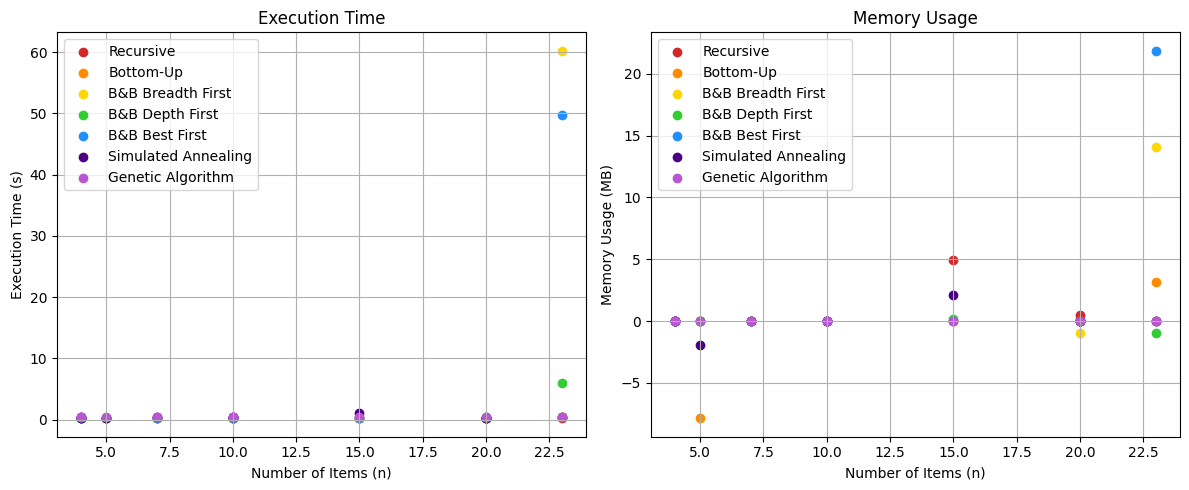

In [10]:
n_values = np.array(n_values)
plt.figure(figsize=(12, 5))

# plot times
plt.subplot(1, 2, 1)
colors = ['tab:red', 'darkorange', 'gold', 'limegreen', 'dodgerblue', 'indigo', 'mediumorchid']
for (method_name, times), color in zip(method_times.items(), colors):
    time_m = np.array(times)  
    plt.scatter(n_values, time_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.title("Execution Time")

# Plot memory usage
plt.subplot(1, 2, 2)
for (method_name, memories), color in zip(method_memory.items(), colors):
    memory_m = np.array(memories) 
    plt.scatter(n_values, memory_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Memory Usage (MB)")
plt.legend()
plt.grid(True)
plt.title("Memory Usage")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Execution Time')

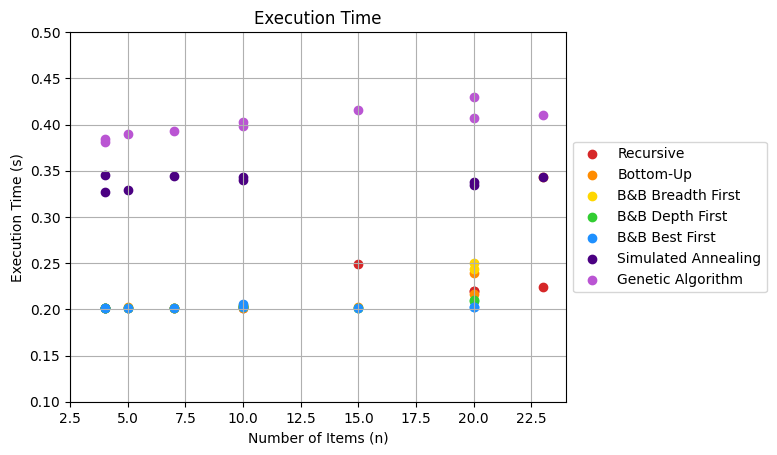

In [11]:
for (method_name, times), color in zip(method_times.items(), colors):
    time_m = np.array(times)  
    plt.scatter(n_values, time_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlim([2.5, 24.0])  
plt.ylim([0.1, 0.5])
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.title("Execution Time")

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <ul>
    <li>Les méthodes B&B ont présenté un temps d'exécution élevé pour le cas où n=23, ce qui peut indiquer que l'arbre avait trop de branches à explorer.</li>
    <li>Les paramètres de SA et GA ont été sélectionnés pour fournir une bonne précision sans exagérer le nombre d'itérations, mais ils ont tout de même affiché des temps d'exécution légèrement plus longs.</li>
    <li>Les méthodes de programmation dynamique se sont révélées très efficaces dans ces exemples à faible dimension.</li>
    <li>Comme les exemples sont petits, l'utilisation de la mémoire n'a pas été considérablement élevée pour aucune des méthodes.</li>
  </ul>
</div>

### Large Scale

In [17]:
def knapsack_genetic(values, weights, W, pop_size=1000, generations=500, mutation_rate=0.05, tournament_size=5):
    num_items = len(values)

    def fitness(individual):
        total_value = np.dot(individual, values)
        total_weight = np.dot(individual, weights)
        return total_value if total_weight <= W else total_value * (W / total_weight)  # Penalization

    def selection(population):
        indices = np.random.choice(len(population), tournament_size, replace=False)
        tournament = population[indices]
        return max(tournament, key=fitness)

    def crossover(parent1, parent2):
        point = np.random.randint(1, num_items)
        child = np.concatenate((parent1[:point], parent2[point:]))
        return child

    def mutation(individual):
        for i in range(num_items):
            if np.random.rand() < mutation_rate:
                individual[i] = 1 - individual[i]
        return individual

    def generate_valid_solution(): # generates a solution by adding itens
        indices = np.argsort(weights)  # Orders itens
        solution = np.zeros(num_items, dtype=int)
        total_weight = 0
        for i in indices:
            if total_weight + weights[i] <= W:
                solution[i] = 1
                total_weight += weights[i]
        return solution

    # Initializes population with valid itens
    population = np.array([generate_valid_solution() for _ in range(pop_size)])

    for _ in range(generations):
        new_population = []
        for _ in range(pop_size):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutation(child)

            while np.dot(child, weights) > W:
                ones = np.where(child == 1)[0]  
                if len(ones) == 0:
                    break 
                child[np.random.choice(ones)] = 0

            new_population.append(child)

        population = np.array(new_population)

    best_individual = max(population, key=fitness)
    return best_individual, fitness(best_individual) 

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Il a été observé que l'algorithme n'a pas réussi à générer une population initiale avec des candidats valides (qui ne dépassaient pas le poids maximal), car le sac à dos dépasse souvent la limite de poids avec seulement 2 ou 3 objets. Cela signifie qu'une méthode adaptée est nécessaire pour initialiser la population initiale.
  </p>
</div>

In [18]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    # path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    # break

knapPI_1_200_1000_1
knapPI_3_2000_1000_1
knapPI_3_1000_1000_1
knapPI_2_200_1000_1
knapPI_3_5000_1000_1
knapPI_2_1000_1000_1
knapPI_3_500_1000_1
knapPI_2_5000_1000_1
knapPI_3_100_1000_1
knapPI_1_2000_1000_1
knapPI_3_200_1000_1
knapPI_2_10000_1000_1
knapPI_1_10000_1000_1
knapPI_1_500_1000_1
knapPI_2_2000_1000_1
knapPI_1_5000_1000_1
knapPI_2_100_1000_1
knapPI_2_500_1000_1
knapPI_1_100_1000_1
knapPI_1_1000_1000_1
knapPI_3_10000_1000_1


In [15]:
methods = {
    "Recursive": knapsack_recursive,
    "Bottom-Up": knapsack_BU,
    "B&B Breadth First": KPBB_BreadthFirst,
    "B&B Depth First": KPBB_DepthFirst,
    "B&B Best First": KPBB_BestFirst,
    "Simulated Annealing": simulated_annealing_knapsack,
    "Genetic Algorithm": knapsack_genetic    
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Large", W_values, N_values)


=== Problem with 200 items and 1000 capacity ===
Recursive, Optimal value: 11238.0
Time: 0.7455s | Memory: 89.0820 MB

Bottom-Up, Optimal value: 11238.0
Time: 0.2977s | Memory: -88.0117 MB

B&B Breadth First, Optimal value: 11238.0
Time: 0.2713s | Memory: 0.0000 MB

B&B Depth First, Optimal value: 11238.0
Time: 0.3203s | Memory: 0.0000 MB

B&B Best First: Interrupted after 3min
Timeout
Time: 180.2010s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 9186.33 ± 872.39
Time: 0.5315s | Memory: 0.0000 MB

Genetic Algorithm, Estimated Best value: 4707.33 ± 552.10
Time: 247.9057s | Memory: 0.0000 MB


=== Problem with 2000 items and 1000 capacity ===


: 

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Il est évident que toutes les méthodes ne sont pas applicables aux exemples de grande échelle :
    <ul>
      <li>La méthode récursive a dépassé le nombre maximal de récursions.</li>
      <li>Les méthodes B&B ont présenté des temps d'exécution trop longs pour être considérées comme valides par rapport à la méthode Bottom-Up.</li>
      <li>Les résultats de l'algorithme génétique étaient significativement inférieurs à la valeur optimale et avaient un temps d'exécution beaucoup plus long. En raison de cela, augmenter les hyperparamètres pour obtenir de meilleurs résultats est irréalisable à cause de l'augmentation excessive du temps d'exécution.</li>
  </p>
</div>

In [20]:
methods = {
    # "Recursive": knapsack_recursive,
    "Bottom-Up": knapsack_BU,
    # "B&B Breadth First": KPBB_BreadthFirst,
    # "B&B Depth First": KPBB_DepthFirst,
    # "B&B Best First": KPBB_BestFirst,
    "Simulated Annealing": simulated_annealing_knapsack,
    # "Genetic Algorithm": knapsack_genetic    
}

n_values, method_times, method_memory = compare_knapsack_methods(methods, datasets, "Large", W_values, N_values)


=== Problem with 200 items and 1000 capacity ===
Bottom-Up, Optimal value: 11238.0
Time: 0.2485s | Memory: 0.0000 MB

Simulated Annealing, Estimated Best value: 11191.20 ± 73.31, Max: 11238.0
Time: 6.5986s | Memory: 0.0000 MB


=== Problem with 2000 items and 1000 capacity ===
Bottom-Up, Optimal value: 7000.0
Time: 1.0661s | Memory: 2.9688 MB

Simulated Annealing, Estimated Best value: 3998.80 ± 586.14, Max: 5099.0
Time: 10.1375s | Memory: -0.9844 MB


=== Problem with 1000 items and 1000 capacity ===
Bottom-Up, Optimal value: 5200.0
Time: 0.6652s | Memory: 2.9570 MB

Simulated Annealing, Estimated Best value: 4318.80 ± 240.93, Max: 4600.0
Time: 8.2395s | Memory: -0.9844 MB


=== Problem with 200 items and 1000 capacity ===
Bottom-Up, Optimal value: 1619.0
Time: 0.2485s | Memory: -0.9766 MB

Simulated Annealing, Estimated Best value: 1543.20 ± 36.04, Max: 1595.0
Time: 6.6045s | Memory: 0.0000 MB


=== Problem with 5000 items and 1000 capacity ===
Bottom-Up, Optimal value: 10200.0
Time

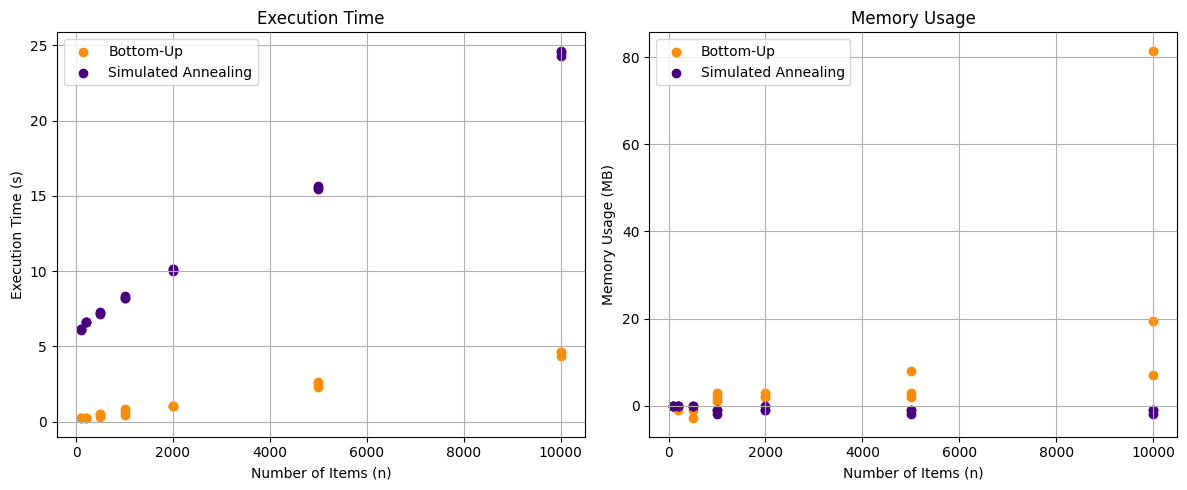

In [21]:
n_values = np.array(n_values)
plt.figure(figsize=(12, 5))

# plot times
plt.subplot(1, 2, 1)
colors = ['darkorange', 'indigo']
for (method_name, times), color in zip(method_times.items(), colors):
    time_m = np.array(times)  
    plt.scatter(n_values, time_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.title("Execution Time")

# Plot memory usage
plt.subplot(1, 2, 2)
for (method_name, memories), color in zip(method_memory.items(), colors):
    memory_m = np.array(memories) 
    plt.scatter(n_values, memory_m, marker='o', linestyle='-', color=color, label=method_name)
plt.xlabel("Number of Items (n)")
plt.ylabel("Memory Usage (MB)")
plt.legend()
plt.grid(True)
plt.title("Memory Usage")

plt.tight_layout()
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Les paramètres de la méthode de Simulated Annealing ont été modifiés dans le but d'atteindre un compromis entre l'approximation du résultat optimal et le temps d'exécution.
  </p>
  <p>
    POn peut voir que la méthode a bien performé seulement dans une partie des exemples de grande échelle, mais n'a pas réussi à atteindre la vitesse de la méthode Bottom-Up. Cependant, elle s'est révélée plus performante en termes d'utilisation de la mémoire.
  </p>
</div>